In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import cartopy.crs as ccrs
import cmocean.cm as cmo
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr

from jaxparrow.cyclogeostrophy import minimization_based
from jaxparrow.geostrophy import geostrophy
from jaxparrow.utils import kinematics, operators


jax.config.update("jax_enable_x64", True)

This notebook demonstrates how regularization can be added to the minimization-based formulation of the cyclogeostrophic inversion problem, to deal with non-balanced SSH signal (for example).

## SWOT SSH observation

We use the filtered SSH (the sum of the variables ``mdt`` and ``ssha_filtered``) measured by SWOT, distributed in version 3.0 of the product from Aviso.

In [3]:
def get_med_sea(swot_ds):
    med_mask = (
        (swot_ds["latitude"] > 30.0681) & (swot_ds["latitude"] < 47.3764) & 
        (swot_ds["longitude"] > -6.0326) & (swot_ds["longitude"] < 42.355)
    )
    swot_ds = swot_ds.where(med_mask, drop=True)

    sea_mask = ~np.isnan(swot_ds["ssha_filtered"])
    min_lat, max_lat = swot_ds["latitude"].where(sea_mask).min(), swot_ds["latitude"].where(sea_mask).max()
    min_lon, max_lon = swot_ds["longitude"].where(sea_mask).min(), swot_ds["longitude"].where(sea_mask).max()
    
    swot_ds = swot_ds.where(
        (swot_ds["latitude"] >= min_lat) & (swot_ds["latitude"] <= max_lat) &
        (swot_ds["longitude"] >= min_lon) & (swot_ds["longitude"] <= max_lon),
        drop=True
    )

    return swot_ds


swot_003_ds = xr.open_dataset("data/SWOT/SWOT_L3_LR_SSH_Expert_506_003_20230429T184429_20230429T193535_v3.0.nc")
swot_003_ds = get_med_sea(swot_003_ds)

We can see that this SSH signal is relatively smooth, but shows small structures that are likely not balanced.

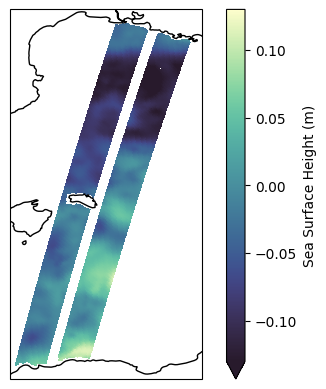

In [4]:
qm = (swot_003_ds.ssha_filtered + swot_003_ds.mdt).plot.pcolormesh(
    x="longitude", y="latitude", 
    cmap=cmo.deep_r, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Sea Surface Height (m)"},
    subplot_kws={"projection": ccrs.PlateCarree()}
)

qm.axes.coastlines()

plt.show()

## Regularization

We will see the impact of adding a vorticity regularization term with respect to either the cyclogeostrophic velocity field, the geostrophic velocity field, the SSH field, or the implied geostrophic field.

In all cases, it simply resolves to writing a JAX-friendly regularization function taking as arguments the latitude and longitude arrays, and the relevant fields, and returning a scalar value. Additional arguments can also be provided, we refer the reader to the API documentation of the [`minimization_based`](../api.md#jaxparrow.cyclogeostrophy.minimization_based) function.

### Gradient flow and the choice of regularization target

The choice of which field to regularize has important consequences for the optimization dynamics:

- **Regularization on cyclogeostrophic velocities** ($u_{cg}$, $v_{cg}$): Both the cyclogeostrophic imbalance and the regularization act on the *same* optimization variables. The optimizer finds a proper trade-off between physical consistency and smoothness. This is a well-posed variational problem with a single gradient path.

- **Regularization on SSH or geostrophic velocities** ($u_g$, $v_g$): These fields become additional optimization variables, but their gradients from the cyclogeostrophic imbalance are stopped (via ``jax.lax.stop_gradient``). This effectively decouples the problem into two independent optimizations running simultaneously: the regularization smooths its target blind to the cyclogeostrophic physics, while $u_{cg}$/$v_{cg}$ chase an evolving target that doesn't know about smoothness. This is pragmatically close to pre-smoothing SSH and then running the standard inversion. It is necessary to stop the gradients, otherwise the optimization problem becomes ill-posed.

- **Regularization on the implied geostrophic field**: A middle ground. The implied geostrophic velocities are derived from the cyclogeostrophic balance ($u_g = u_{cg} + v_{adv}/f$), so they are a function of $u_{cg}$/$v_{cg}$ only. Regularizing them keeps a single gradient path while targeting the geostrophic level of the solution.

In [5]:
lat = jnp.asarray(swot_003_ds.latitude.values)
lon = jnp.asarray(swot_003_ds.longitude.values)
ssh = jnp.asarray((swot_003_ds.ssha_filtered + swot_003_ds.mdt).values)

mb_results_noreg = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3))
)

### With respect to the cyclogeostrophic velocity field

In this case the signature (i.e. the parameters) of the regularization function must contain ``ucg_t`` and ``vcg_t`` as arguments for the components of the cyclogeostrophic velocity field, and ``lat_t`` and ``lon_t`` as arguments for the grid coordinate arrays. The order of the arguments does not matter, but their exact spelling does.

The regularization function can contain any instructions that are compatible with JAX ``grad`` and ``jit`` barriers.
Here we simply use the [`vorticity`](../api.md#jaxparrow.kinematics.vorticity) function from ``jaxparrow`` to compute the relative vorticity of the velocity field, we square it, and we return its sum over the whole geographical domain.

In [6]:
lambda_reg_cg = 1e-1

def regularization_cg(ucg_t, vcg_t, lat_t, lon_t):
    vort = kinematics.vorticity(ucg_t, vcg_t, lat_t, lon_t)
    reg = lambda_reg_cg * jnp.nansum(vort**2)
    return reg

We then pass this function as an argument to [`minimization_based`](../api.md#jaxparrow.cyclogeostrophy.minimization_based) when performing the inversion.

In [7]:
mb_results_cg = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), 
    regularization=regularization_cg
)

### With respect to the geostrophic velocity field

As in the previous example, the regularization function must contain ``lat_t`` and ``lon_t`` as arguments for the grid coordinate arrays, and this time ``ug_t`` and ``vg_t`` as arguments for the components of the geostrophic velocity field.

Again, we use the [`vorticity`](../api.md#jaxparrow.kinematics.vorticity) function from ``jaxparrow`` to compute the relative vorticity of the velocity field, but using the geostrophic currents.

In [8]:
lambda_reg_g = 7e-3

def regularization_g(ug_t, vg_t, lat_t, lon_t):
    vort = kinematics.vorticity(ug_t, vg_t, lat_t, lon_t)
    reg = lambda_reg_g * jnp.nansum(vort**2)
    return reg

And we solve the optimization problem.

In [9]:
mb_results_g = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), 
    regularization=regularization_g
)

### With respect to the SSH field

Now only ``ssh_t`` must be provided as an argument for the SSH field (and of course ``lat_t`` and ``lon_t``).

Using the SSH field, we compute the geostrophic currents, from which we get the vorticity (we could have used the Laplacian of the SSH as well).

In [10]:
lambda_reg_ssh = 1e-5

def regularization_ssh(ssh_t, lat_t, lon_t):
    ug, vg = geostrophy(ssh_t, lat_t, lon_t)
    vort = kinematics.vorticity(ug, vg, lat_t, lon_t)
    reg = lambda_reg_ssh * jnp.nansum(vort**2)
    return reg

In [11]:
mb_results_ssh = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), regularization=regularization_ssh
)

### With respect to the implied geostrophic field

Rather than regularizing SSH or $u_g$/$v_g$ directly (which decouples the optimization, as explained above), we can regularize the *implied* geostrophic field — the geostrophic velocities that the current cyclogeostrophic solution implies through the balance equations:

$$u_g^{impl} = u_{cg} + \frac{v_{adv}}{f}, \quad v_g^{impl} = v_{cg} - \frac{u_{adv}}{f}$$

Since these are purely a function of $u_{cg}$ and $v_{cg}$, all gradients flow through a single path and the optimizer can make a proper trade-off between physical consistency and geostrophic-level smoothness.

This regularization function makes use of grid metric parameters (``dx_e_t``, ``dy_n_t``, etc.) that are automatically provided by ``minimization_based`` based on the function's signature.

In [ ]:
lambda_reg_ig = 1e-1

def regularization_implied_geos(
    ucg_t, vcg_t, lat_t, lon_t,
    dx_e_t, dx_n_t, dy_e_t, dy_n_t, J_t,
    coriolis_factor_t, land_mask
):
    # Compute advection of cyclogeostrophic velocities
    ducg_e, ducg_n = operators.horizontal_derivatives(
        ucg_t, dx_e=dx_e_t, dx_n=dx_n_t, dy_e=dy_e_t, dy_n=dy_n_t, J=J_t, land_mask=land_mask
    )
    dvcg_e, dvcg_n = operators.horizontal_derivatives(
        vcg_t, dx_e=dx_e_t, dx_n=dx_n_t, dy_e=dy_e_t, dy_n=dy_n_t, J=J_t, land_mask=land_mask
    )
    u_adv = ucg_t * ducg_e + vcg_t * ducg_n
    v_adv = ucg_t * dvcg_e + vcg_t * dvcg_n

    # Implied geostrophic velocities from the cyclogeostrophic balance
    ug_implied = ucg_t + v_adv / coriolis_factor_t
    vg_implied = vcg_t - u_adv / coriolis_factor_t

    vort = kinematics.vorticity(ug_implied, vg_implied, lat_t, lon_t)
    return lambda_reg_ig * jnp.nansum(vort**2)

In [13]:
mb_results_ig = minimization_based(
    lat_t=lat, lon_t=lon, ssh_t=ssh, 
    optim=optax.chain(optax.clip(1), optax.sgd(learning_rate=5e-3)), 
    regularization=regularization_implied_geos
)

## Comparison

We now visually observe the difference between the SSH, cyclogeostrophic velocity, and cyclogeostrophic relative vorticity fields obtained from the different regularization variants (including no regularization).

In [14]:
ssh_reg_cg = mb_results_cg.ssh if mb_results_cg.ssh is not None else ssh
ssh_reg_ig = mb_results_ig.ssh if mb_results_ig.ssh is not None else ssh
ssh_reg_g = mb_results_g.ssh if mb_results_g.ssh is not None else ssh
ssh_reg_ssh = mb_results_ssh.ssh if mb_results_ssh.ssh is not None else ssh

ucg_reg_cg = mb_results_cg.ucg
ucg_reg_ig = mb_results_ig.ucg
ucg_reg_g = mb_results_g.ucg
ucg_reg_ssh = mb_results_ssh.ucg
ucg_noreg = mb_results_noreg.ucg

vcg_reg_cg = mb_results_cg.vcg
vcg_reg_ig = mb_results_ig.vcg
vcg_reg_g = mb_results_g.vcg
vcg_reg_ssh = mb_results_ssh.vcg
vcg_noreg = mb_results_noreg.vcg

In [15]:
uvcg_reg_cg = kinematics.magnitude(ucg_reg_cg, vcg_reg_cg)
uvcg_reg_ig = kinematics.magnitude(ucg_reg_ig, vcg_reg_ig)
uvcg_reg_g = kinematics.magnitude(ucg_reg_g, vcg_reg_g)
uvcg_reg_ssh = kinematics.magnitude(ucg_reg_ssh, vcg_reg_ssh)
uvcg_noreg = kinematics.magnitude(ucg_noreg, vcg_noreg)

rv_reg_cg = kinematics.vorticity(ucg_reg_cg, vcg_reg_cg, lat, lon)
rv_reg_ig = kinematics.vorticity(ucg_reg_ig, vcg_reg_ig, lat, lon)
rv_reg_g = kinematics.vorticity(ucg_reg_g, vcg_reg_g, lat, lon)
rv_reg_ssh = kinematics.vorticity(ucg_reg_ssh, vcg_reg_ssh, lat, lon)
rv_noreg = kinematics.vorticity(ucg_noreg, vcg_noreg, lat, lon)

In [16]:
def make_da(data):
    return xr.DataArray(
        data,
        coords={"latitude": swot_003_ds["latitude"], "longitude": swot_003_ds["longitude"]},
        dims=("num_lines", "num_pixels"),
    )

ssh_noreg_da = make_da(ssh)
ssh_reg_cg_da = make_da(ssh_reg_cg)
ssh_reg_ig_da = make_da(ssh_reg_ig)
ssh_reg_g_da = make_da(ssh_reg_g)
ssh_reg_ssh_da = make_da(ssh_reg_ssh)

uvcg_noreg_da = make_da(uvcg_noreg)
uvcg_reg_cg_da = make_da(uvcg_reg_cg)
uvcg_reg_ig_da = make_da(uvcg_reg_ig)
uvcg_reg_g_da = make_da(uvcg_reg_g)
uvcg_reg_ssh_da = make_da(uvcg_reg_ssh)

rv_noreg_da = make_da(rv_noreg)
rv_reg_cg_da = make_da(rv_reg_cg)
rv_reg_ig_da = make_da(rv_reg_ig)
rv_reg_g_da = make_da(rv_reg_g)
rv_reg_ssh_da = make_da(rv_reg_ssh)

In [17]:
methods = ["None", "Cyclogeos.", "Impl. geos.", "Geos.", "SSH"]

ssh_da = xr.concat(
    [ssh_noreg_da, ssh_reg_cg_da, ssh_reg_ig_da, ssh_reg_g_da, ssh_reg_ssh_da], 
    dim=xr.Variable("regularization", methods)
)
uvcg_da = xr.concat(
    [uvcg_noreg_da, uvcg_reg_cg_da, uvcg_reg_ig_da, uvcg_reg_g_da, uvcg_reg_ssh_da], 
    dim=xr.Variable("regularization", methods)
)
rv_da = xr.concat(
    [rv_noreg_da, rv_reg_cg_da, rv_reg_ig_da, rv_reg_g_da, rv_reg_ssh_da], 
    dim=xr.Variable("regularization", methods)
)

In [18]:
row_labels = methods[:-1]  # subtracted from
col_labels = methods[1:]   # subtracted

def build_diff_da(fields):
    diff_data = np.full((len(row_labels), len(col_labels)) + fields[0].shape, np.nan)
    for i in range(len(row_labels)):
        for j in range(len(col_labels)):
            if i <= j:  # upper triangle
                diff_data[i, j] = np.array(fields[j + 1] - fields[i])
    return xr.DataArray(
        diff_data,
        dims=("row", "col", "num_lines", "num_pixels"),
        coords={
            "row": row_labels, "col": col_labels,
            "latitude": (("num_lines", "num_pixels"), swot_003_ds["latitude"].values),
            "longitude": (("num_lines", "num_pixels"), swot_003_ds["longitude"].values),
        },
    )

def plot_diff_triangle(da, cmap, cbar_label):
    fg = da.plot.pcolormesh(
        x="longitude", y="latitude", row="row", col="col",
        cmap=cmap, robust=True, add_colorbar=True,
        cbar_kwargs={"label": cbar_label, "aspect": 35},
        figsize=(10, 12),
        subplot_kws={"projection": ccrs.PlateCarree()},
    )
    fg.set_titles("{value}")
    for i, ax in enumerate(fg.axs.flat):
        row_idx, col_idx = divmod(i, len(col_labels))
        if row_idx > col_idx:
            ax.set_visible(False)
        else:
            ax.coastlines()
    plt.show()

For the SSH field, only the one from the variant in which the regularization is performed directly on the SSH was modified.

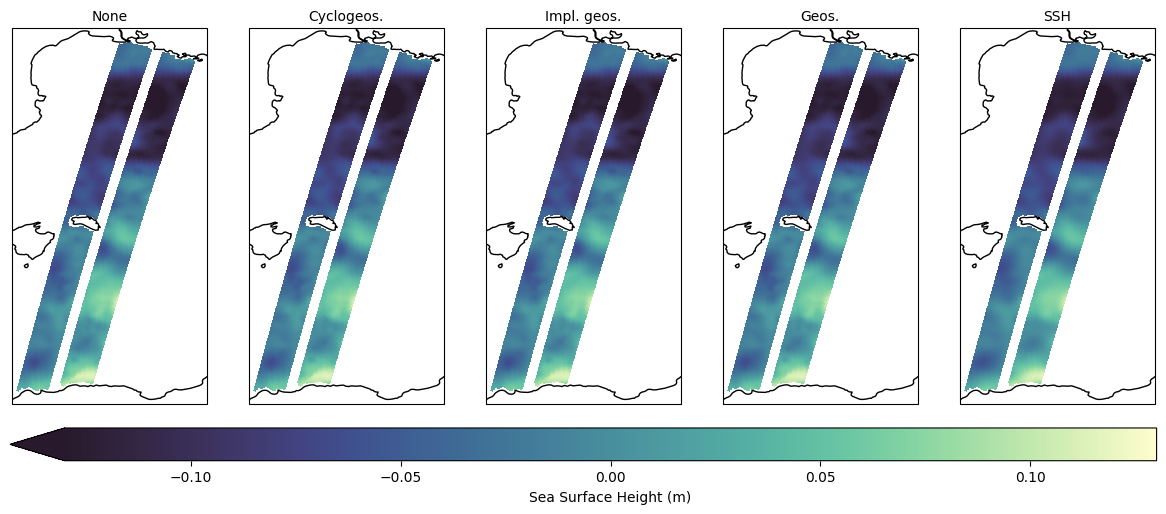

In [34]:
fg = ssh_da.plot.pcolormesh(
    x="longitude", y="latitude", col="regularization",
    cmap=cmo.deep_r, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Sea Surface Height (m)", "location": "bottom", "shrink": 0.98, "aspect": 35, "pad": 0.05},
    figsize=(12, 5), subplot_kws={"projection": ccrs.PlateCarree()}
)

fg.set_titles("{value}")
for ax in fg.axs.flat:
    ax.coastlines()

plt.show()

And when looking at the difference between the fields, we see that we filtered some small-scale structures.

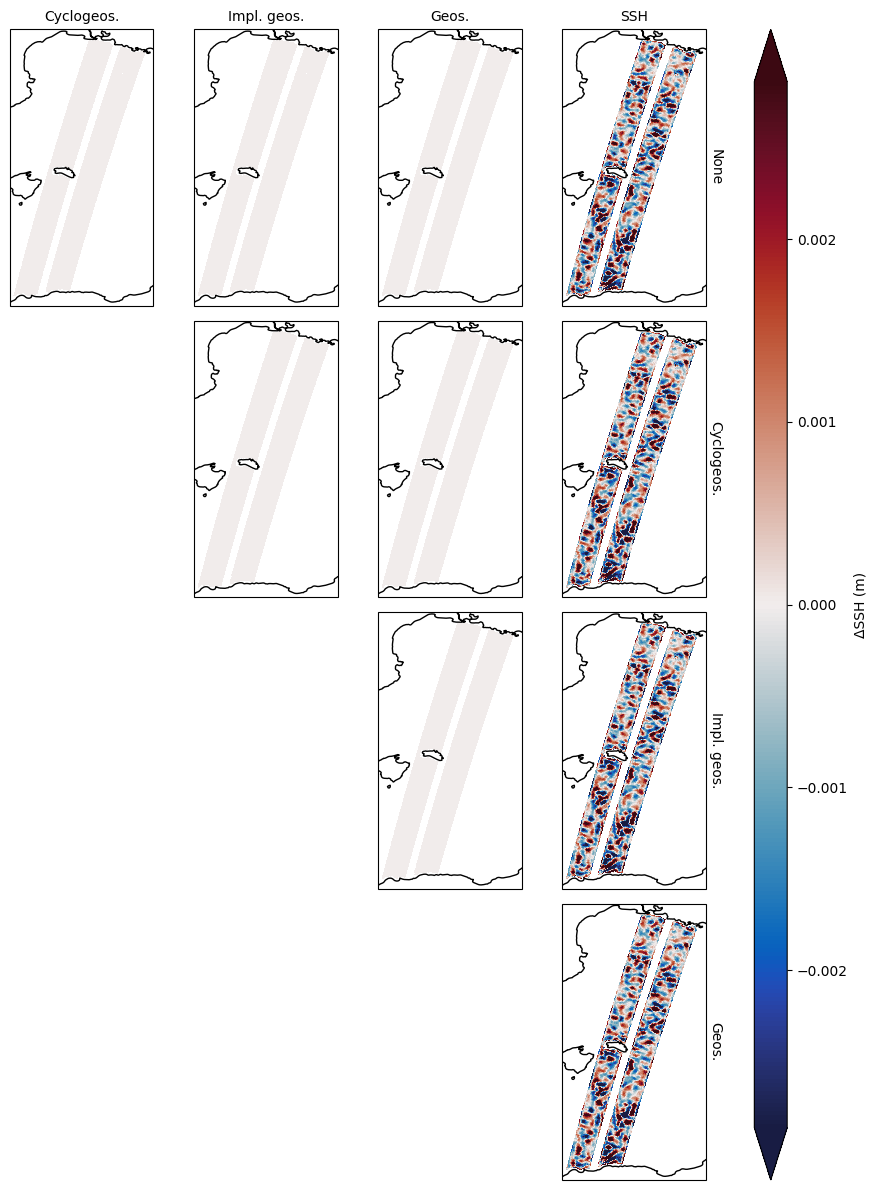

In [20]:
ssh_diff_da = build_diff_da([ssh_noreg_da, ssh_reg_cg_da, ssh_reg_ig_da, ssh_reg_g_da, ssh_reg_ssh_da])
plot_diff_triangle(ssh_diff_da, cmo.balance, "ΔSSH (m)")

The cyclogeostrophic velocity fields are this time all different from one another, and we again see that the regularization variants filtered out some small structures.

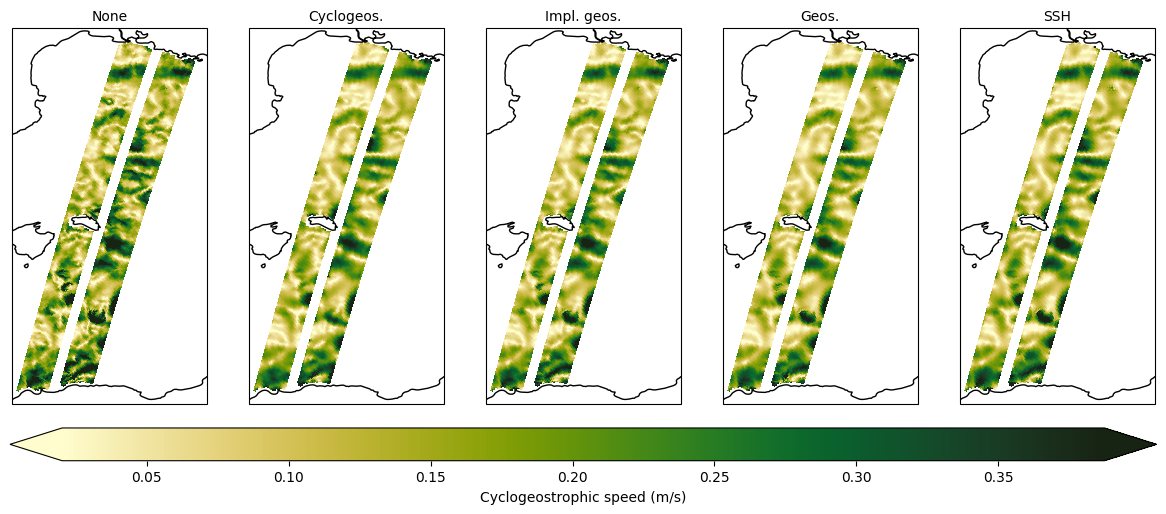

In [35]:
fg = uvcg_da.plot.pcolormesh(
    x="longitude", y="latitude", col="regularization",
    cmap=cmo.speed, add_colorbar=True, robust=True,
    cbar_kwargs={
        "label": "Cyclogeostrophic speed (m/s)", "location": "bottom", "shrink": 0.98, "aspect": 35, "pad": 0.05
    },
    figsize=(12, 5), subplot_kws={"projection": ccrs.PlateCarree()}
)

fg.set_titles("{value}")
for ax in fg.axs.flat:
    ax.coastlines()

plt.show()

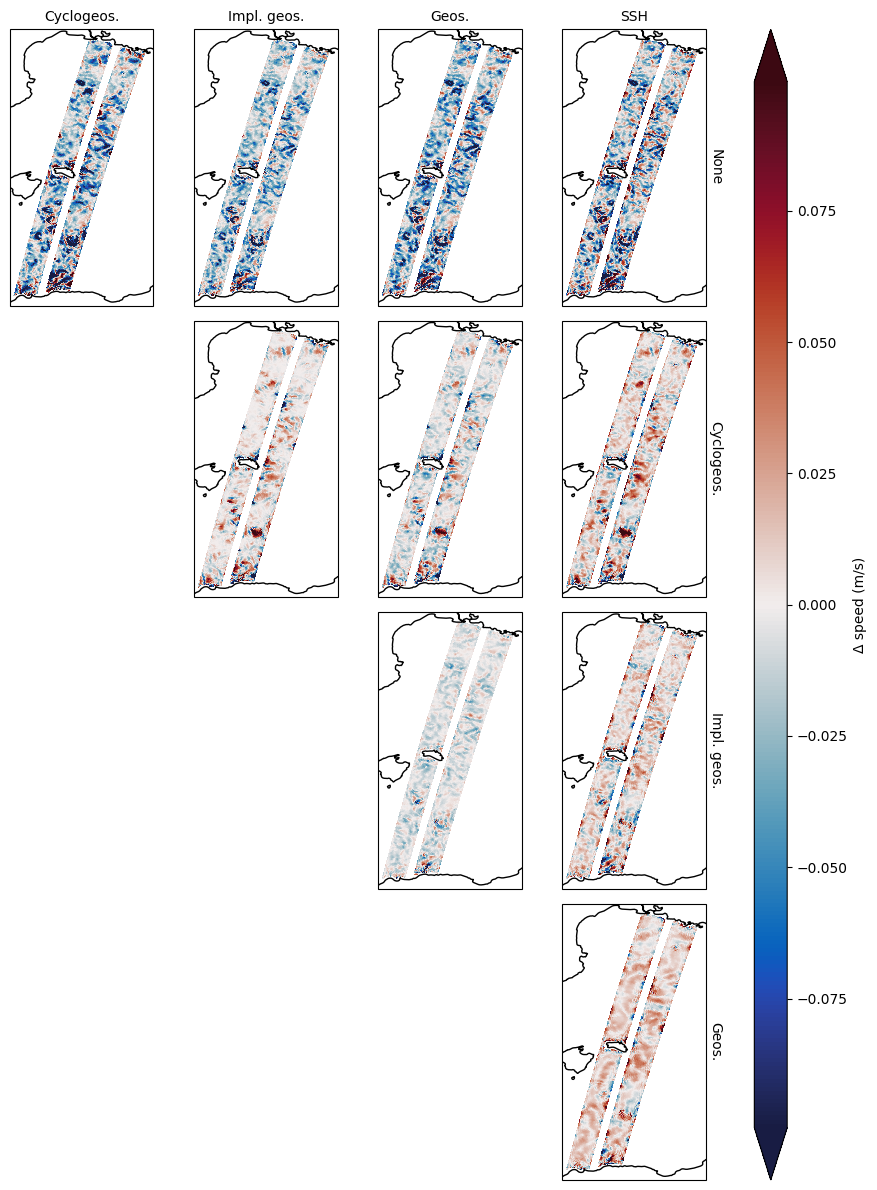

In [22]:
uvcg_diff_da = build_diff_da([uvcg_noreg_da, uvcg_reg_cg_da, uvcg_reg_ig_da, uvcg_reg_g_da, uvcg_reg_ssh_da])
plot_diff_triangle(uvcg_diff_da, cmo.balance, "Δ speed (m/s)")

Finally, when inspecting the relative vorticity fields, we observe that the ones obtained with the regularization applied to the cyclogeostrophic velocity and to the implied geostrophic field are overall smoother and look physically more consistent than the others.

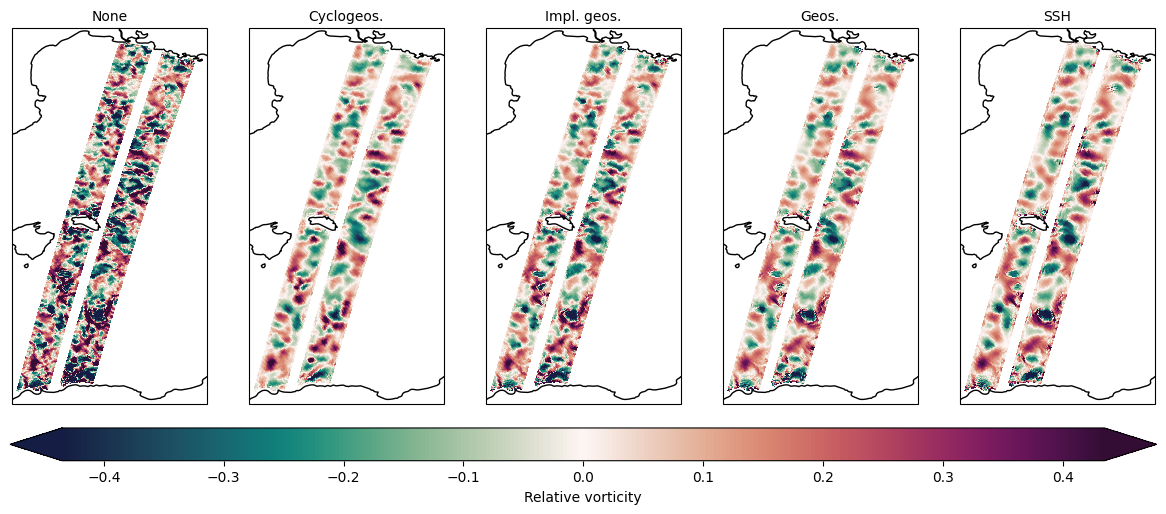

In [36]:
fg = rv_da.plot.pcolormesh(
    x="longitude", y="latitude", col="regularization",
    cmap=cmo.curl, add_colorbar=True, robust=True,
    cbar_kwargs={"label": "Relative vorticity", "location": "bottom", "shrink": 0.98, "aspect": 35, "pad": 0.05},
    figsize=(12, 5), subplot_kws={"projection": ccrs.PlateCarree()}
)

fg.set_titles("{value}")
for ax in fg.axs.flat:
    ax.coastlines()

plt.show()

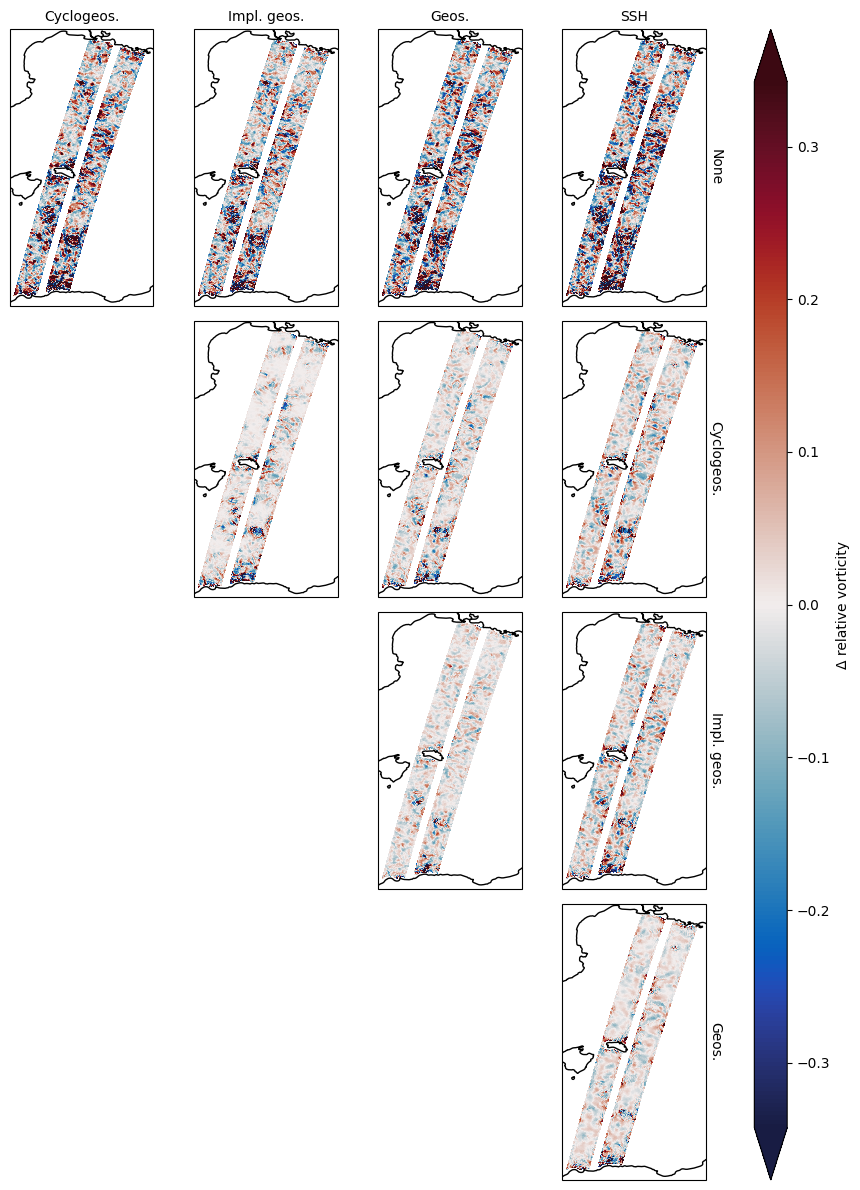

In [24]:
rv_diff_da = build_diff_da([rv_noreg_da, rv_reg_cg_da, rv_reg_ig_da, rv_reg_g_da, rv_reg_ssh_da])
plot_diff_triangle(rv_diff_da, cmo.balance, "Δ relative vorticity")

## Discussion

The results above illustrate the impact of the gradient flow topology on regularization effectiveness:

- **Cyclogeostrophic** and **implied geostrophic** regularization produce the smoothest vorticity fields. This is expected: both the cyclogeostrophic imbalance and the regularization act on the same optimization variables ($u_{cg}$, $v_{cg}$), so the optimizer finds a proper trade-off between physical consistency and smoothness.

- **Geostrophic** and **SSH** regularization are less effective. Because ``stop_gradient`` decouples the optimization, the regularization smooths its target blind to the physics — this is pragmatically equivalent to pre-smoothing the SSH field and then running the standard inversion. The two objectives (physics and smoothness) do not compete on the same variables, so no meaningful trade-off is achieved.

- The **implied geostrophic** approach offers an interesting middle ground: it regularizes the geostrophic level of the solution (rather than the cyclogeostrophic velocities directly) while maintaining a unified gradient path through $u_{cg}$/$v_{cg}$. This can be useful when the desired smoothness constraint is more naturally expressed in terms of the geostrophic field, or the SSH field (retrieve from geostrophic currents by inverting the Poisson equation $\nabla^2 \eta = \frac{f}{g} \left( \frac{\partial v_g}{\partial x} - \frac{\partial u_g}{\partial y} \right)$).